## Import Library

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


## Import Preprocessing

In [55]:
from preprocessing2 import (
    df_zscore, df_zscore_drop, df_zscore_replace,
    df_log, df_log_drop, df_log_replace,
    df_minmax, df_minmax_drop, df_minmax_replace,
    df_decimal, df_decimal_drop, df_decimal_replace,
)

print('Semua dataset berhasil diimport!')

Semua dataset berhasil diimport!


## Model Input

In [56]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

def run_lgbm(df, dataset_name, test_size=0.2, random_state=42):
    df_clean = df.copy()
    
    # Drop ID kalau ada
    if 'Loan_ID' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Loan_ID'])

    # Split fitur & target
    X = df_clean.drop(columns=['Loan_Status'])
    y = df_clean['Loan_Status']

    # Train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Model LightGBM
    lgbm = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=-1,
        random_state=random_state
    )

    # Training
    lgbm.fit(X_train, y_train)

    # Prediksi
    y_pred = lgbm.predict(X_test)

    return {
        'Dataset'   : dataset_name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 Score'  : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'cm'        : confusion_matrix(y_test, y_pred),
        'model'     : lgbm,
        'X_train'   : X_train,
        'X_test'    : X_test,
        'feature_names': X.columns.tolist(),
    }

print('Fungsi LightGBM siap!')

Fungsi LightGBM siap!


## Training Model

In [57]:
datasets = {
    'ZScore (Original)' : df_zscore,
    'ZScore (Drop)'     : df_zscore_drop,
    'ZScore (Replace)'  : df_zscore_replace,
    'Log (Original)'    : df_log,
    'Log (Drop)'        : df_log_drop,
    'Log (Replace)'     : df_log_replace,
    'MinMax (Original)' : df_minmax,
    'MinMax (Drop)'     : df_minmax_drop,
    'MinMax (Replace)'  : df_minmax_replace,
    'Decimal (Original)': df_decimal,
    'Decimal (Drop)'    : df_decimal_drop,
    'Decimal (Replace)' : df_decimal_replace,
}

results = {}
for name, data in datasets.items():
    print(f'Training: {name} ...')
    results[name] = run_lgbm(data, name)

print('\nSemua model selesai ditraining!')

Training: ZScore (Original) ...
[LightGBM] [Info] Number of positive: 337, number of negative: 154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 544
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.686354 -> initscore=0.783130
[LightGBM] [Info] Start training from score 0.783130
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

## Tabel Perbandingan

In [58]:
summary = pd.DataFrame([
    {
        'Dataset'   : r['Dataset'],
        'Accuracy'  : r['Accuracy'],
        'Precision' : r['Precision'],
        'Recall'    : r['Recall'],
        'F1 Score'  : r['F1 Score'],
    }
    for r in results.values()
]).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

           Dataset  Accuracy  Precision  Recall  F1 Score
    Decimal (Drop)    0.8824     0.8718  0.9714    0.9189
        Log (Drop)    0.8824     0.8718  0.9714    0.9189
     ZScore (Drop)    0.8627     0.8684  0.9429    0.9041
     MinMax (Drop)    0.8627     0.8684  0.9429    0.9041
 MinMax (Original)    0.8537     0.8764  0.9176    0.8966
 ZScore (Original)    0.8374     0.8652  0.9059    0.8851
  ZScore (Replace)    0.8293     0.8636  0.8941    0.8786
    Log (Original)    0.8211     0.8462  0.9059    0.8750
Decimal (Original)    0.8211     0.8462  0.9059    0.8750
     Log (Replace)    0.8211     0.8621  0.8824    0.8721
  MinMax (Replace)    0.8211     0.8621  0.8824    0.8721
 Decimal (Replace)    0.8211     0.8621  0.8824    0.8721


## Visualisasi Matrix

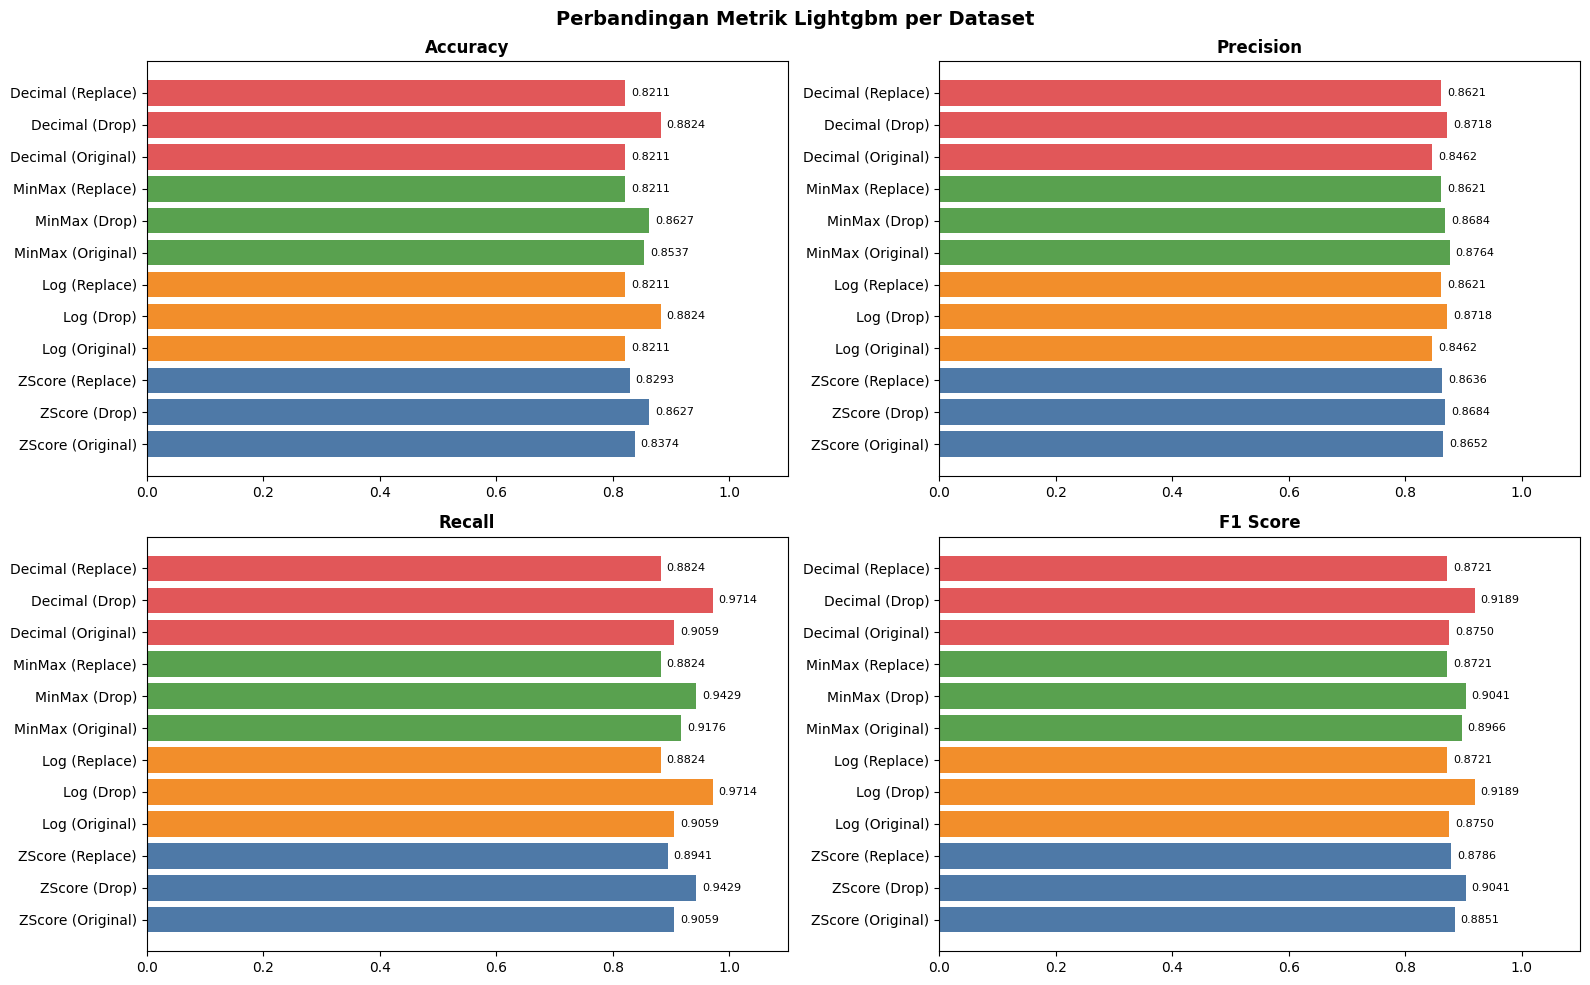

In [59]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors  = ['#4e79a7']*3 + ['#f28e2b']*3 + ['#59a14f']*3 + ['#e15759']*3

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Perbandingan Metrik Lightgbm per Dataset', fontsize=14, fontweight='bold')

for ax, metric in zip(axes.flatten(), metrics):
    vals = [results[n][metric] for n in datasets]
    bars = ax.barh(list(datasets.keys()), vals, color=colors)
    ax.set_xlim(0, 1.1)
    ax.set_title(metric, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Confusion Matrix Semua Dataset

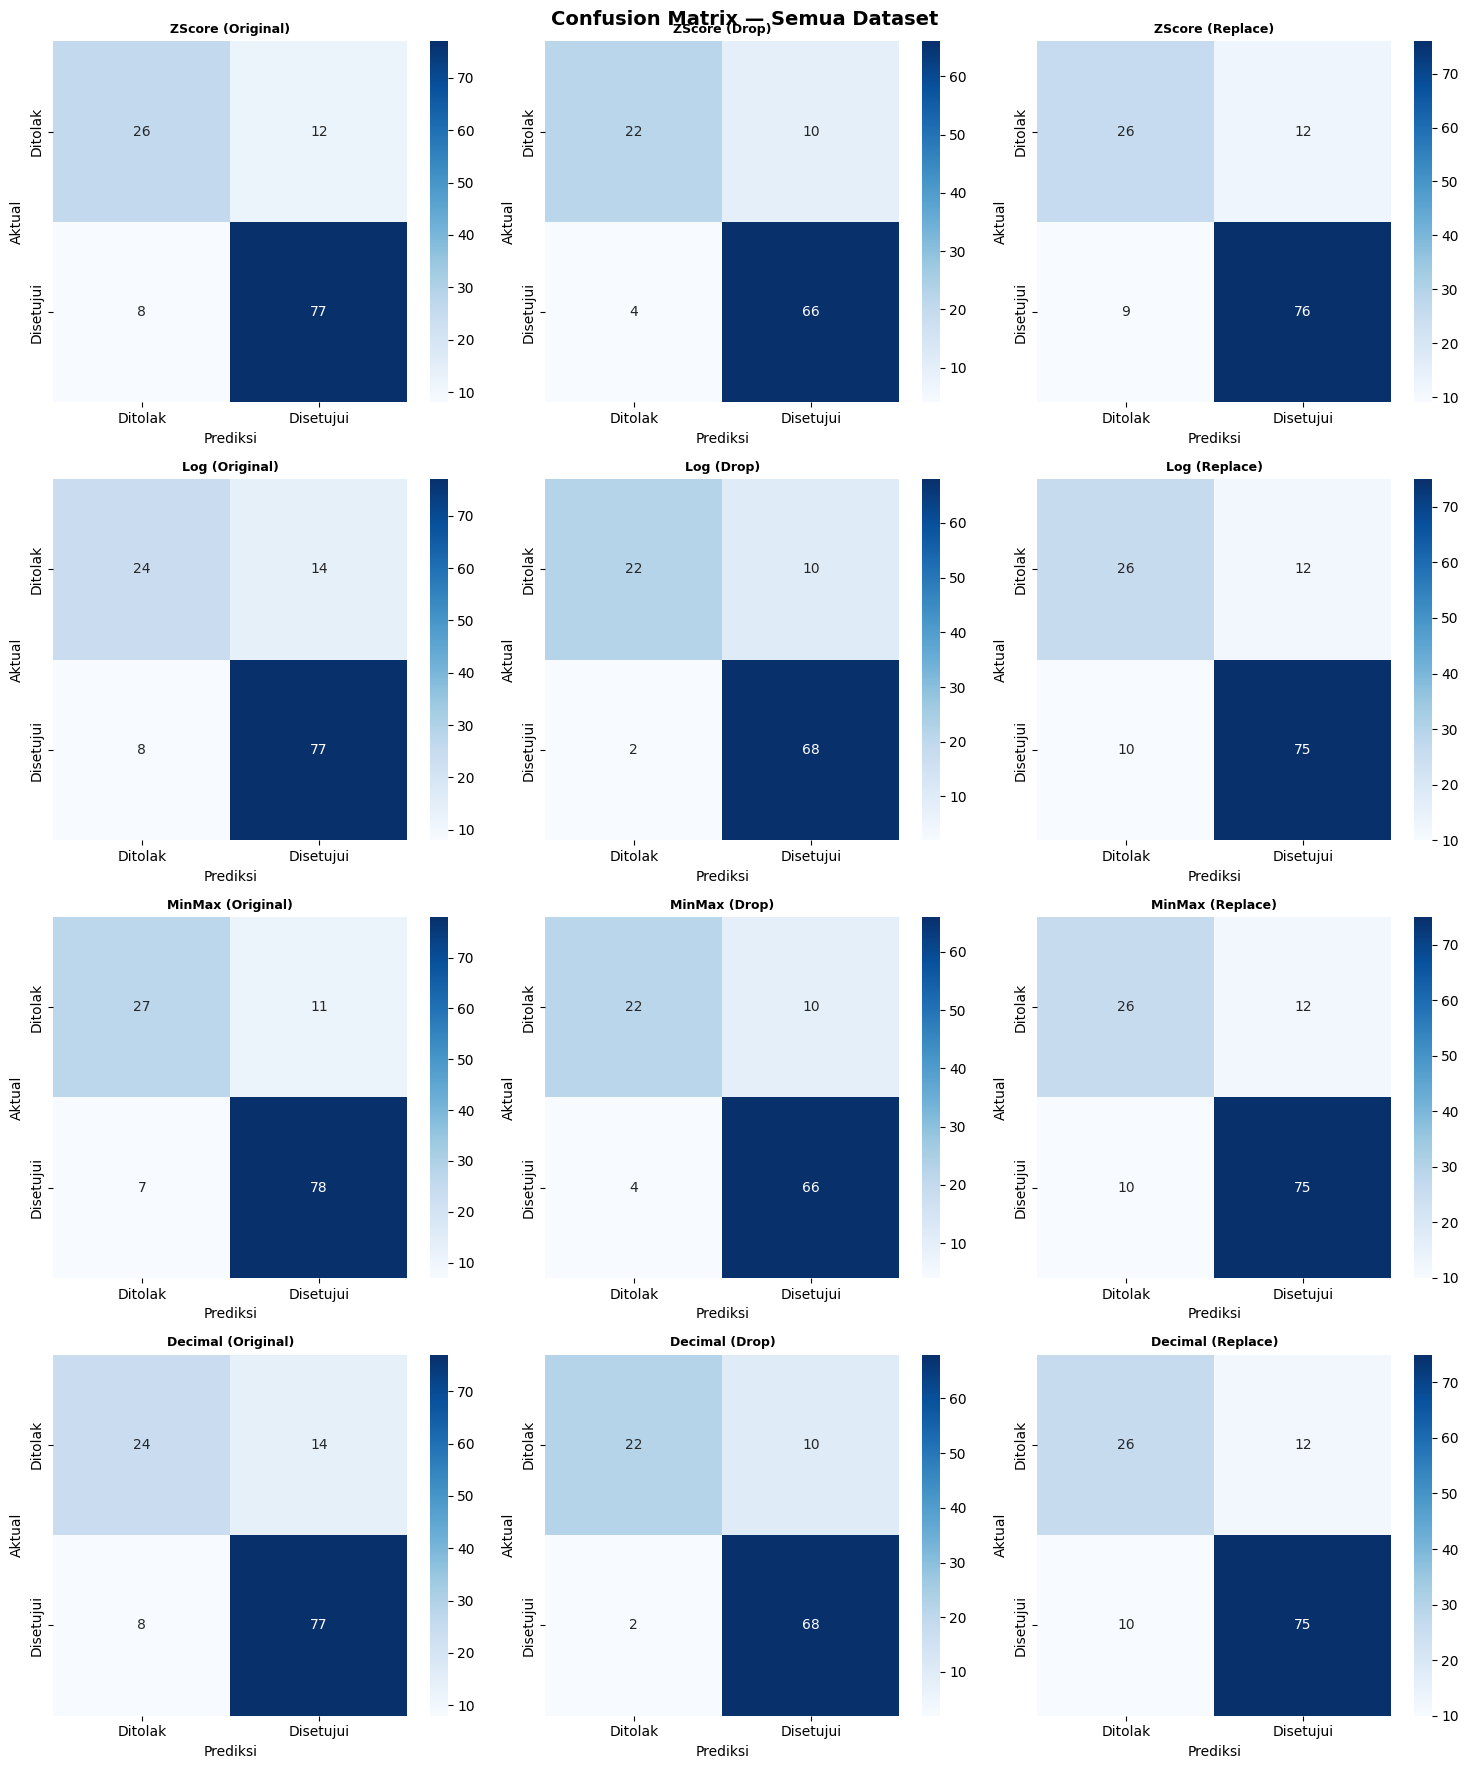

In [60]:
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
fig.suptitle('Confusion Matrix — Semua Dataset', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flatten(), results.items()):
    sns.heatmap(
        res['cm'], annot=True, fmt='d', cmap='Blues',
        xticklabels=['Ditolak','Disetujui'],
        yticklabels=['Ditolak','Disetujui'],
        ax=ax
    )
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')

plt.tight_layout()
plt.show()

## Clasification Report Detail

In [61]:
for name, res in results.items():
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(
        res['y_test'], res['y_pred'],
        target_names=['Ditolak (0)', 'Disetujui (1)'],
        zero_division=0
    ))
    print()

  ZScore (Original)
               precision    recall  f1-score   support

  Ditolak (0)       0.76      0.68      0.72        38
Disetujui (1)       0.87      0.91      0.89        85

     accuracy                           0.84       123
    macro avg       0.81      0.80      0.80       123
 weighted avg       0.83      0.84      0.83       123


  ZScore (Drop)
               precision    recall  f1-score   support

  Ditolak (0)       0.85      0.69      0.76        32
Disetujui (1)       0.87      0.94      0.90        70

     accuracy                           0.86       102
    macro avg       0.86      0.82      0.83       102
 weighted avg       0.86      0.86      0.86       102


  ZScore (Replace)
               precision    recall  f1-score   support

  Ditolak (0)       0.74      0.68      0.71        38
Disetujui (1)       0.86      0.89      0.88        85

     accuracy                           0.83       123
    macro avg       0.80      0.79      0.80       123


## Prediksi

In [62]:
# ── Isi data baru sesuai kebutuhan ─────────────────────────────────
new_data_raw = {
    'Gender'            : 1,
    'Married'           : 1,
    'Dependents'        : 0.0,
    'Education'         : 1,
    'Self_Employed'     : 0,
    'ApplicantIncome'   : 5000,
    'CoapplicantIncome' : 1500,
    'LoanAmount'        : 150,
    'Loan_Amount_Term'  : 360,
    'Credit_History'    : 1.0,
    'Property_Area'     : 1,
    'Total_Income'      : 6500,
}

new_df = pd.DataFrame([new_data_raw])
print('Data baru:')
print(new_df.T)

Data baru:
                        0
Gender                1.0
Married               1.0
Dependents            0.0
Education             1.0
Self_Employed         0.0
ApplicantIncome    5000.0
CoapplicantIncome  1500.0
LoanAmount          150.0
Loan_Amount_Term    360.0
Credit_History        1.0
Property_Area         1.0
Total_Income       6500.0


## Hasil Prediksi Semua Model

In [63]:
print('HASIL PREDIKSI DATA BARU — SEMUA MODEL')
print('='*60)

new_pred_records = []

for name, res in results.items():
    cols  = res['feature_names']
    model = res['model']

    if not all(c in new_df.columns for c in cols):
        print(f'{name:30s} : Kolom tidak lengkap, skip')
        continue

    pred_raw   = model.predict(new_df[cols])[0]
    pred_label = 1 if pred_raw >= 0.5 else 0
    status     = 'DISETUJUI ✅' if pred_label == 1 else 'DITOLAK ❌'

    print(f'{name:30s} : {status}  (raw={pred_raw:.4f})')
    new_pred_records.append({
        'Dataset' : name,
        'Raw'     : round(pred_raw, 4),
        'Label'   : pred_label,
        'Status'  : 'Disetujui' if pred_label == 1 else 'Ditolak'
    })

pred_df = pd.DataFrame(new_pred_records)
print('='*60)
print(f"Disetujui: {(pred_df['Label']==1).sum()} model | Ditolak: {(pred_df['Label']==0).sum()} model")

HASIL PREDIKSI DATA BARU — SEMUA MODEL
ZScore (Original)              : DISETUJUI ✅  (raw=1.0000)
ZScore (Drop)                  : DISETUJUI ✅  (raw=1.0000)
ZScore (Replace)               : DISETUJUI ✅  (raw=1.0000)
Log (Original)                 : DITOLAK ❌  (raw=0.0000)
Log (Drop)                     : DISETUJUI ✅  (raw=1.0000)
Log (Replace)                  : DISETUJUI ✅  (raw=1.0000)
MinMax (Original)              : DISETUJUI ✅  (raw=1.0000)
MinMax (Drop)                  : DISETUJUI ✅  (raw=1.0000)
MinMax (Replace)               : DISETUJUI ✅  (raw=1.0000)
Decimal (Original)             : DISETUJUI ✅  (raw=1.0000)
Decimal (Drop)                 : DISETUJUI ✅  (raw=1.0000)
Decimal (Replace)              : DISETUJUI ✅  (raw=1.0000)
Disetujui: 11 model | Ditolak: 1 model
